# Lotka Volterra (4 parameters) test case  

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from data_collection import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)



True

In [2]:
# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

In [3]:
import itertools

# Define the intervals and number of points
num_points = 5  # Number of points in each linspace (adjust as needed)
# first_interval = np.linspace(2, 3.2, num_points)
# second_interval = np.linspace(0.6, 1.9, num_points)
# third_interval = np.linspace(0.6, 1.9, num_points)
# fourth_interval = np.linspace(0.8, 2.1, num_points)
first_interval = np.linspace(2.1, 3, num_points)
second_interval = np.linspace(0.9, 1.5, num_points)
third_interval = np.linspace(0.9, 1.5, num_points)
fourth_interval = np.linspace(1., 2.1, num_points)
# Generate all combinations using itertools.product
combinations = list(itertools.product(first_interval, second_interval, third_interval, fourth_interval))

# Convert the combinations to a numpy array
combinations_array = np.array(combinations)

# Shuffle the rows of the array
np.random.shuffle(combinations_array)

print(combinations_array)

[[3.    1.2   1.05  1.55 ]
 [3.    0.9   0.9   1.   ]
 [2.775 1.05  1.05  1.55 ]
 ...
 [3.    1.05  0.9   1.55 ]
 [2.325 0.9   0.9   1.   ]
 [2.55  0.9   1.35  1.   ]]


In [4]:
combinations_array.shape

(625, 4)

In [5]:
# reproducibility
seed = 7
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

In [6]:
solver_HF = System2()
solver_LF = System2()

num_params=4
params=combinations_array[0:10,:]

(t_HF,y_HF,mu_HF)=solver_HF.generate_dataset(T=5.0, params=params, h=0.01, fidelity='HF')
solver_HF.save_dataset('dataset_HF_4params.h5')

(t_LF,y_LF,mu_LF)=solver_LF.generate_dataset(T=5.0, params=params, h=0.04, fidelity='LF')
solver_LF.save_dataset('dataset_LF_4params.h5')


In [7]:
len(y_HF)

10

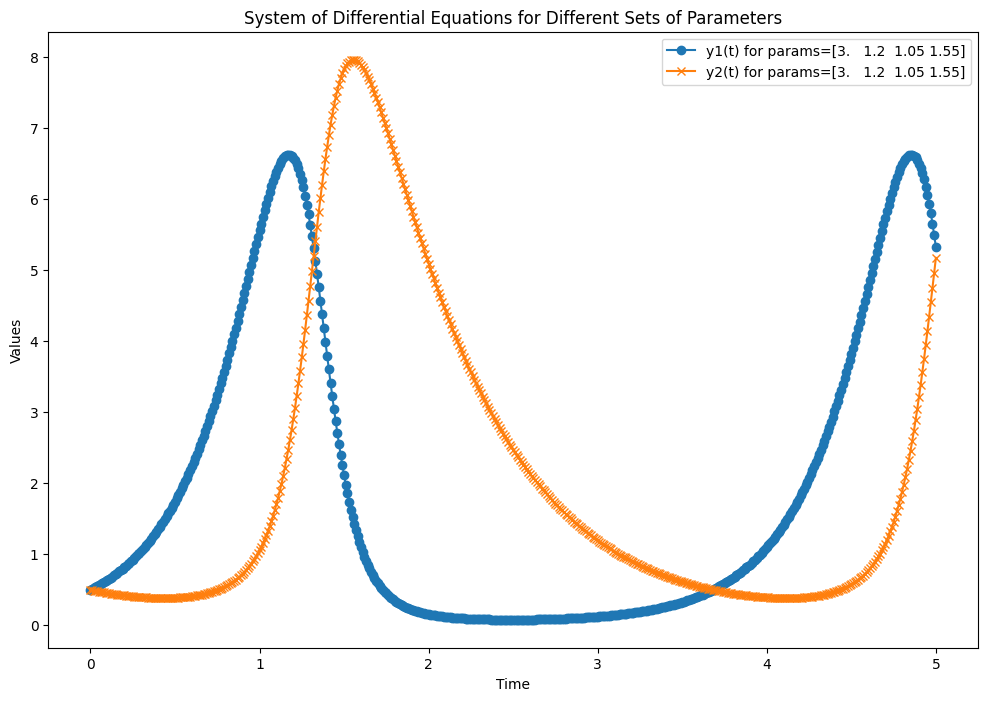

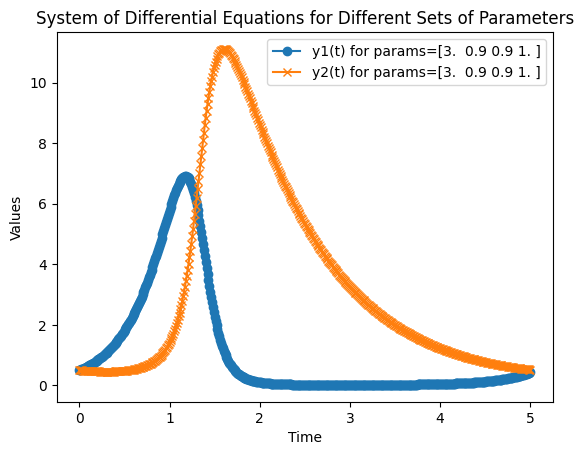

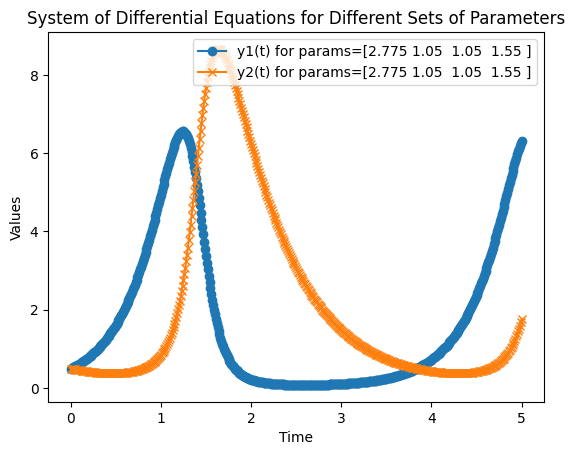

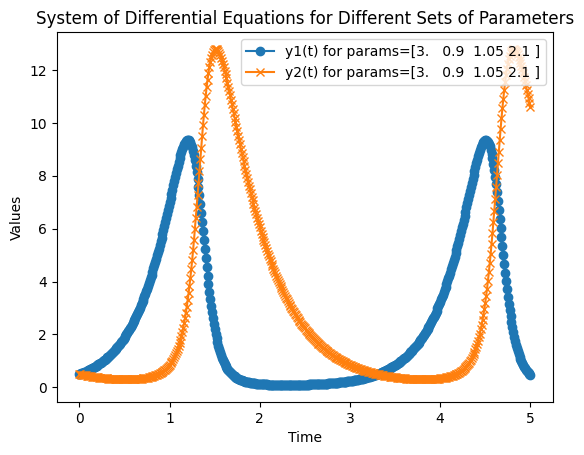

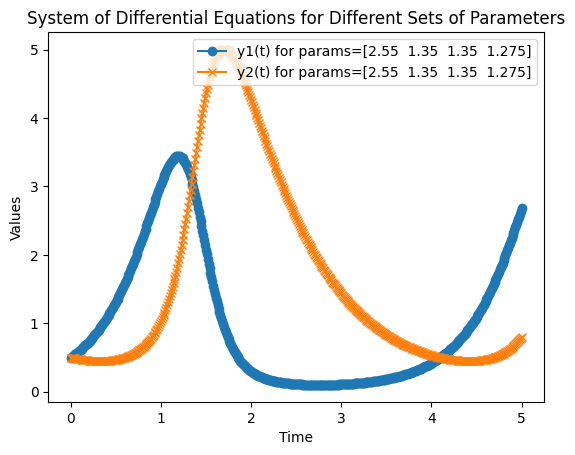

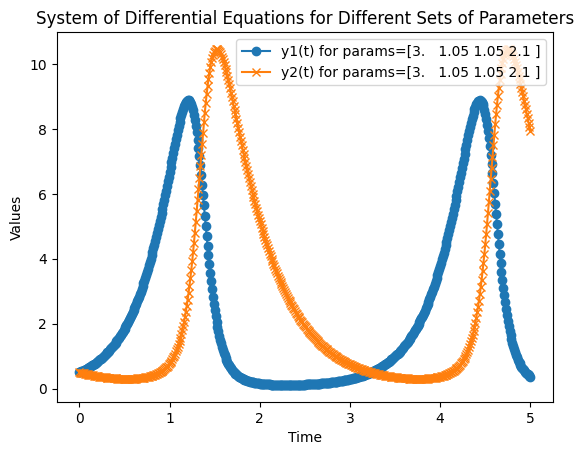

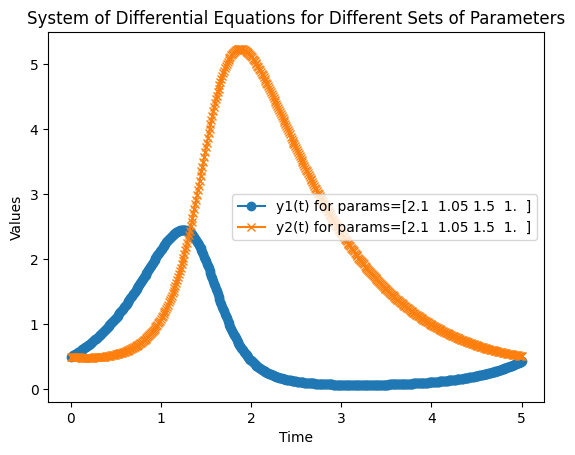

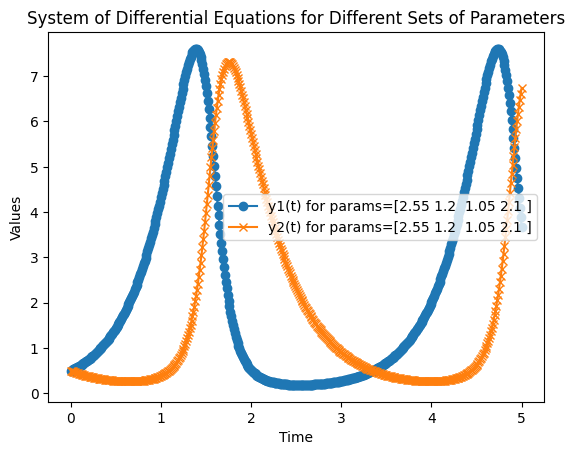

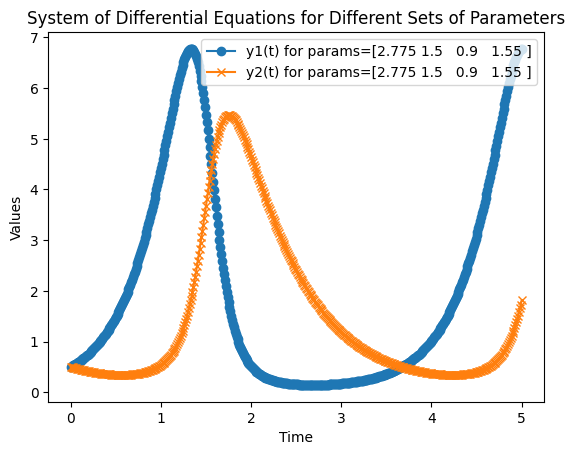

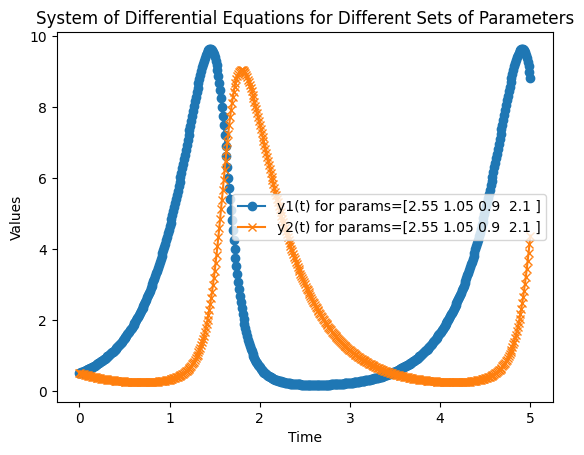

In [8]:
solver_HF.plot_results()

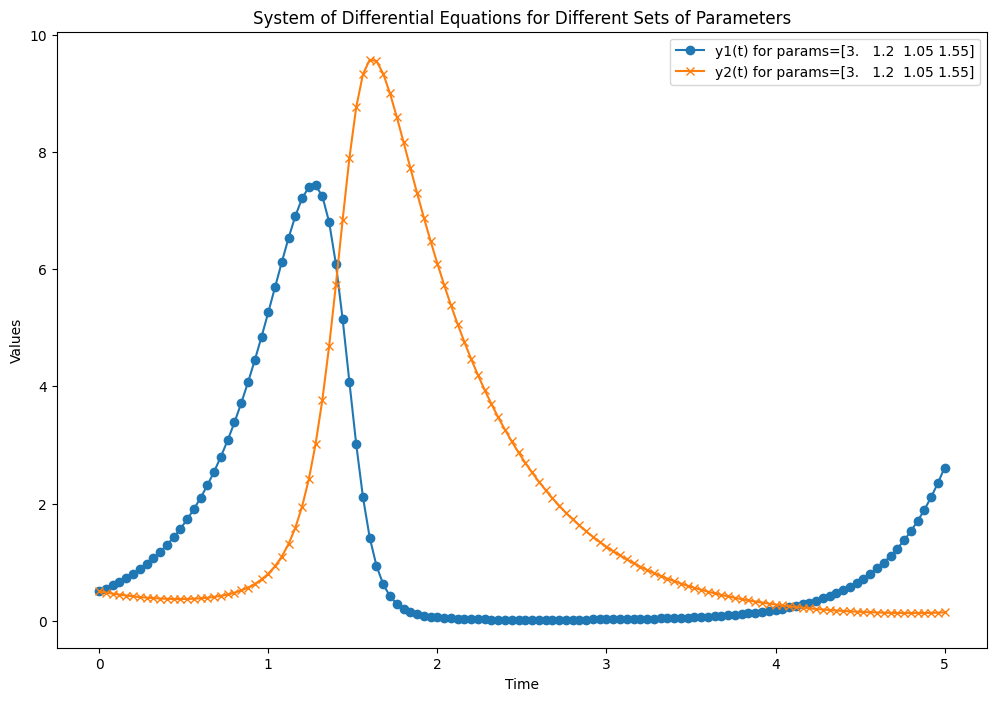

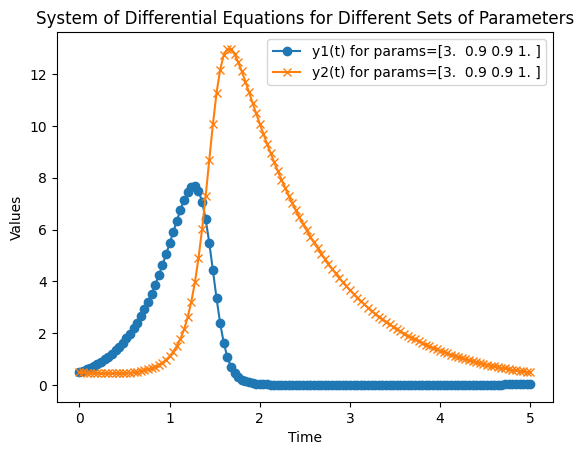

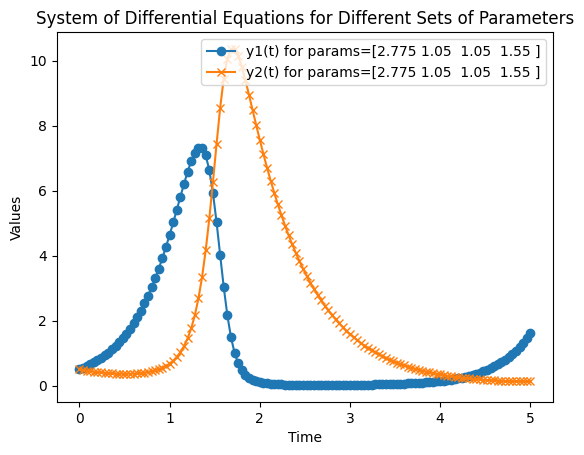

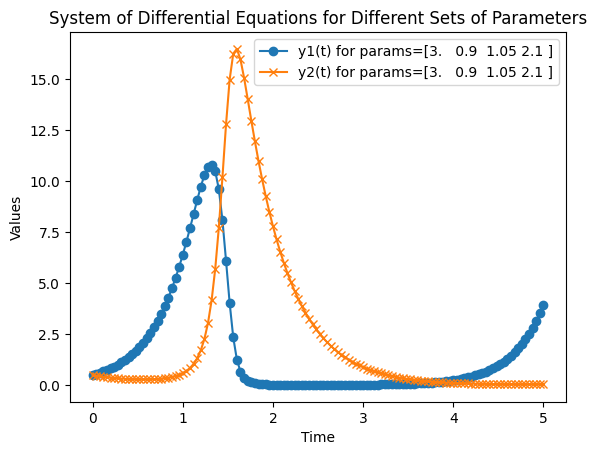

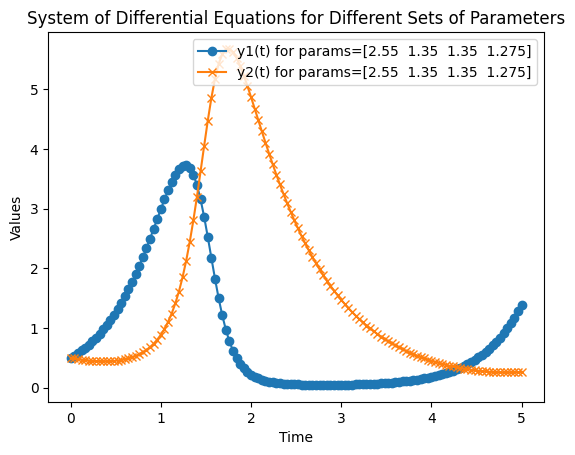

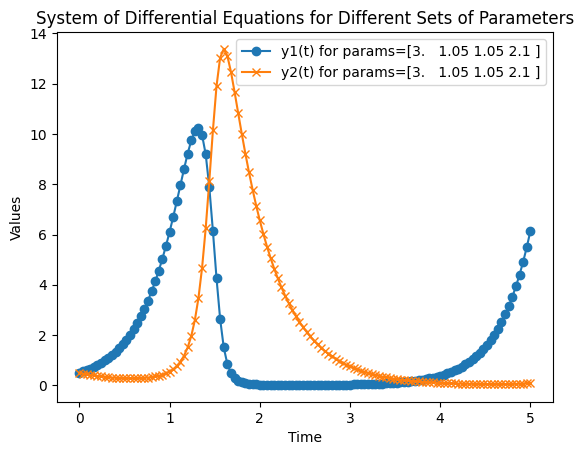

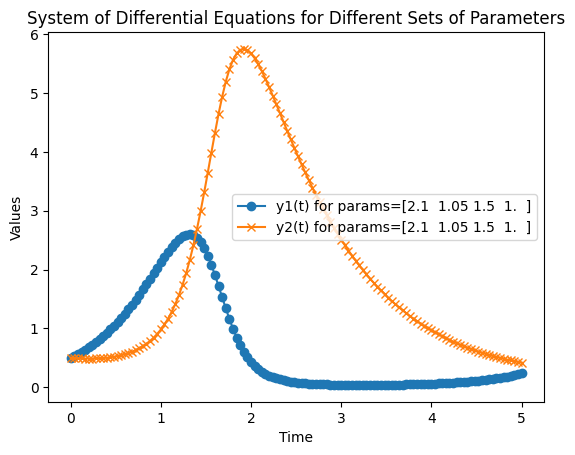

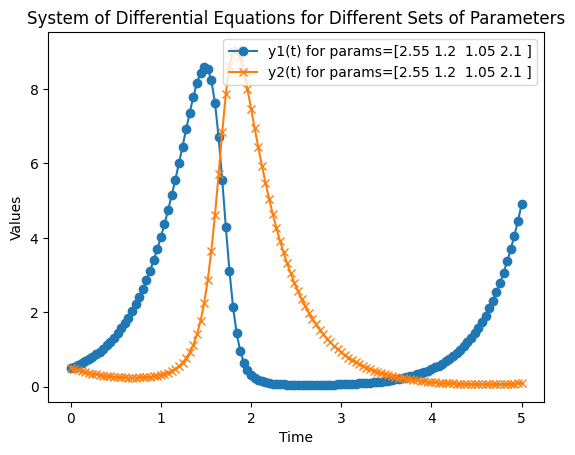

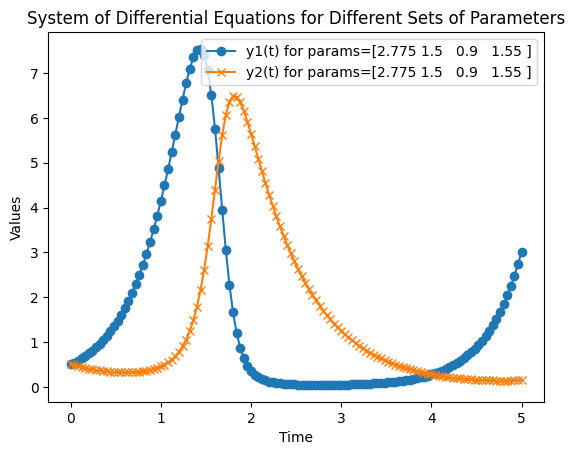

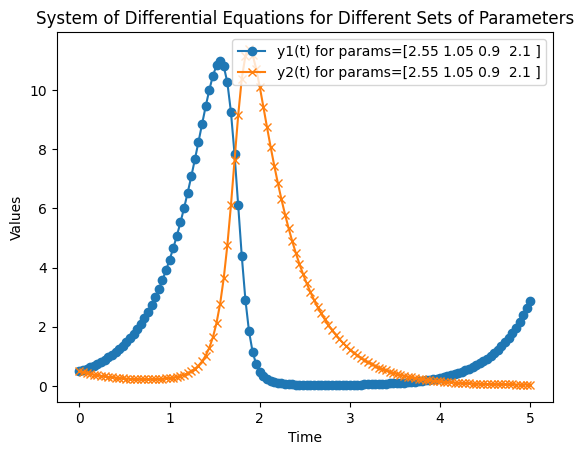

In [9]:
solver_LF.plot_results()

In [10]:
mu_HF.shape

(10, 4)

In [11]:
t_HF.shape

(501,)

In [12]:
t_HF.shape

(501,)

In [13]:
np.array(np.meshgrid(mu_HF,t_HF))#.T.reshape(-1, num_params+1)

array([[[3.  , 1.2 , 1.05, ..., 1.05, 0.9 , 2.1 ],
        [3.  , 1.2 , 1.05, ..., 1.05, 0.9 , 2.1 ],
        [3.  , 1.2 , 1.05, ..., 1.05, 0.9 , 2.1 ],
        ...,
        [3.  , 1.2 , 1.05, ..., 1.05, 0.9 , 2.1 ],
        [3.  , 1.2 , 1.05, ..., 1.05, 0.9 , 2.1 ],
        [3.  , 1.2 , 1.05, ..., 1.05, 0.9 , 2.1 ]],

       [[0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
        [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
        [0.02, 0.02, 0.02, ..., 0.02, 0.02, 0.02],
        ...,
        [4.98, 4.98, 4.98, ..., 4.98, 4.98, 4.98],
        [4.99, 4.99, 4.99, ..., 4.99, 4.99, 4.99],
        [5.  , 5.  , 5.  , ..., 5.  , 5.  , 5.  ]]])

In [14]:
# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_HF.shape[0]), np.arange(t_HF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_HF = np.hstack((t_HF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_HF[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_LF.shape[0]), np.arange(t_LF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_LF = np.hstack((t_LF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_LF[cartesian_product_indices[:, 0]]))


In [15]:
x_LF.shape

(1260, 5)

In [16]:
y_HF=np.array(y_HF).reshape(-1, solver_HF.get_dim())
y_LF=np.array(y_LF).reshape(-1, solver_LF.get_dim())

In [17]:
y_HF.shape

(5010, 2)

The function training took 23.723140 seconds.


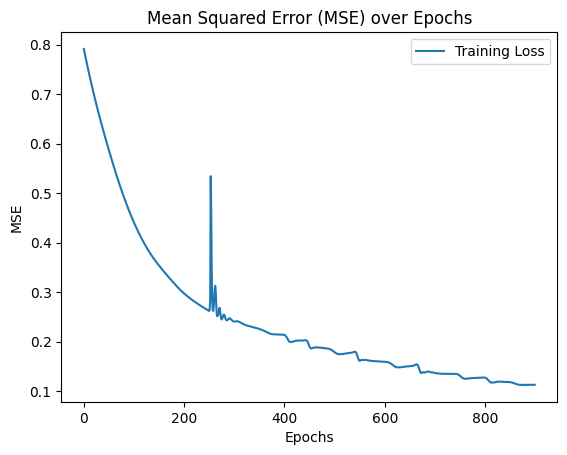

The function training took 269.975519 seconds.


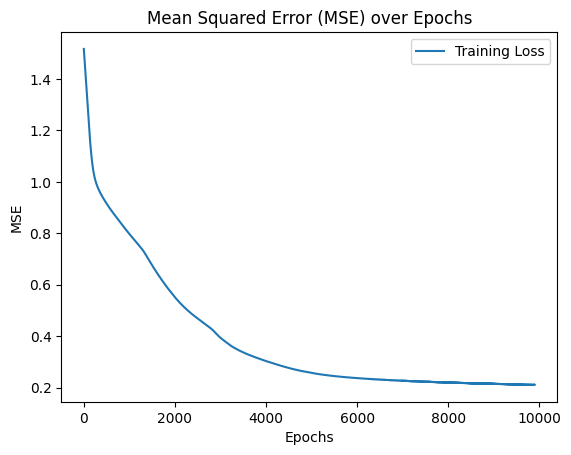

Test MSE: 0.54565357255293
R^2: 0.8767951511961206


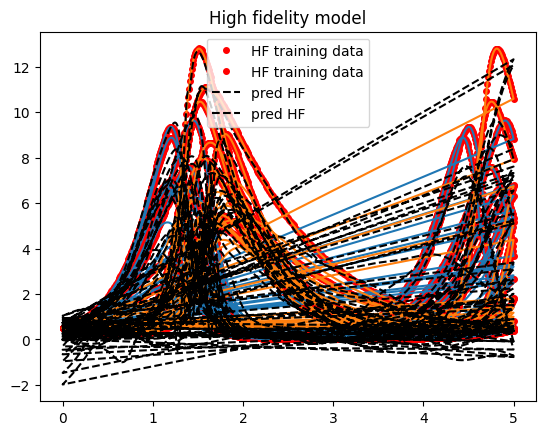

In [18]:
N=[1000,10000]
n=[500,1000]
names = ['LF', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF,x_HF],
    "output_train": [y_LF, y_HF],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System2()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=5.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


# Plotting data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1, 2))
plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title
plt.legend()
plt.title('High fidelity model')

# Show the plot
plt.show()

The function training took 1.994957 seconds.


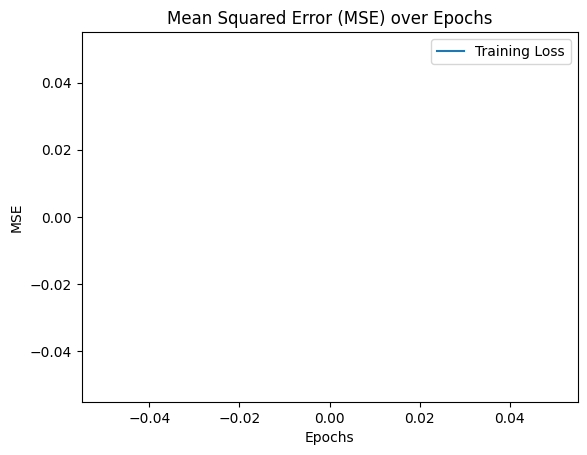

The function training took 31.436821 seconds.


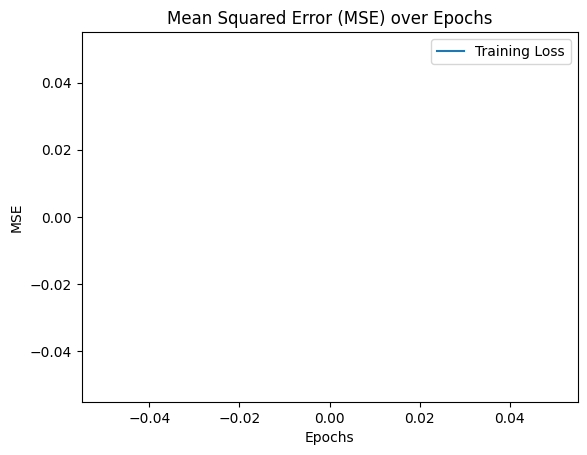

Test MSE: 1.0980160584027174
R^2: 0.7520754756047789


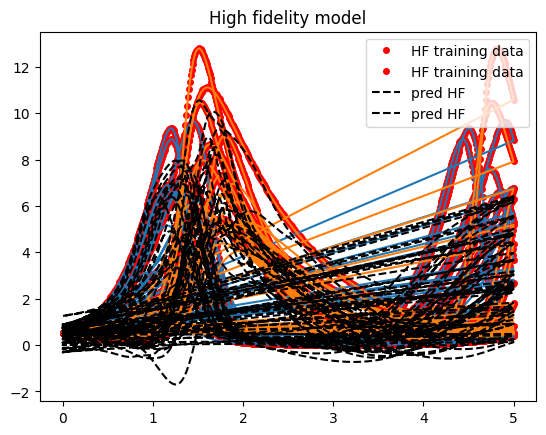

In [18]:
N=[10,100]
n=[5,10]
names = ['LF', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF,x_HF],
    "output_train": [y_LF, y_HF],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System2()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=5.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


# Plotting data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1, 2))
plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title
plt.legend()
plt.title('High fidelity model')

# Show the plot
plt.show()

Sampling 2 chains in parallel


2024-08-11 01:14:00,585	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\s

Estimated values are [2.508 0.9   0.523 0.854]
     mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
x0  2.508  0.0   2.508    2.508        0.0      0.0      20.0      20.0    NaN
x1  0.900  0.0   0.900    0.900        0.0      0.0      20.0      20.0    NaN
x2  0.523  0.0   0.523    0.523        0.0      0.0      20.0      20.0    NaN
x3  0.854  0.0   0.854    0.854        0.0      0.0      20.0      20.0    NaN
----  Autocorrelation  ----
----  Effective Sample Size  ----
----  Effective Sample Size per iteration  ----
----  Rank Plots  ----


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


The difference between estimated values [0.492 0.3   0.827 0.971]



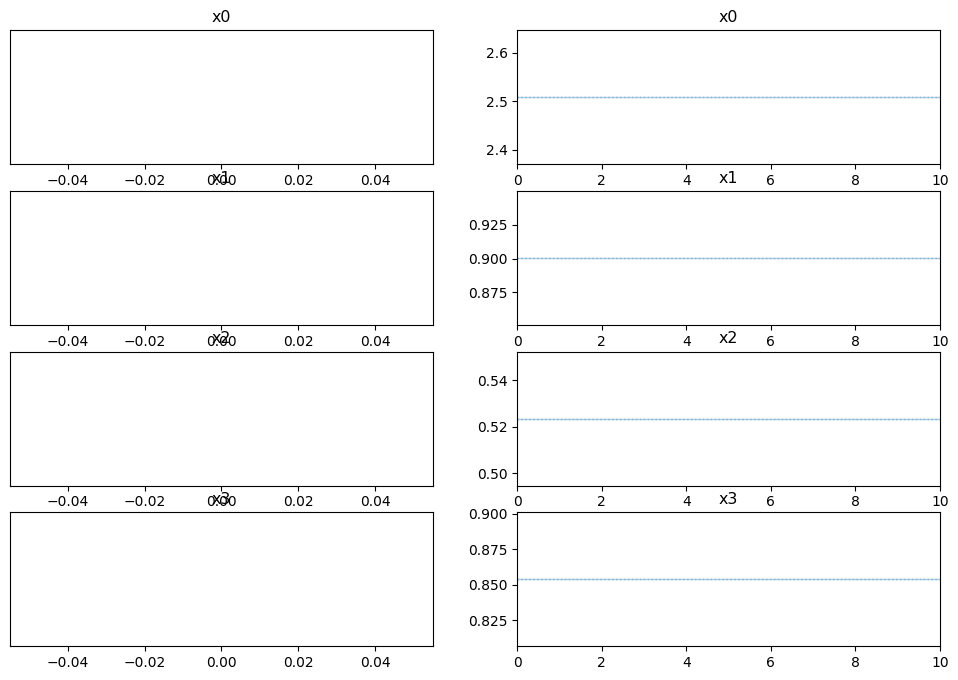

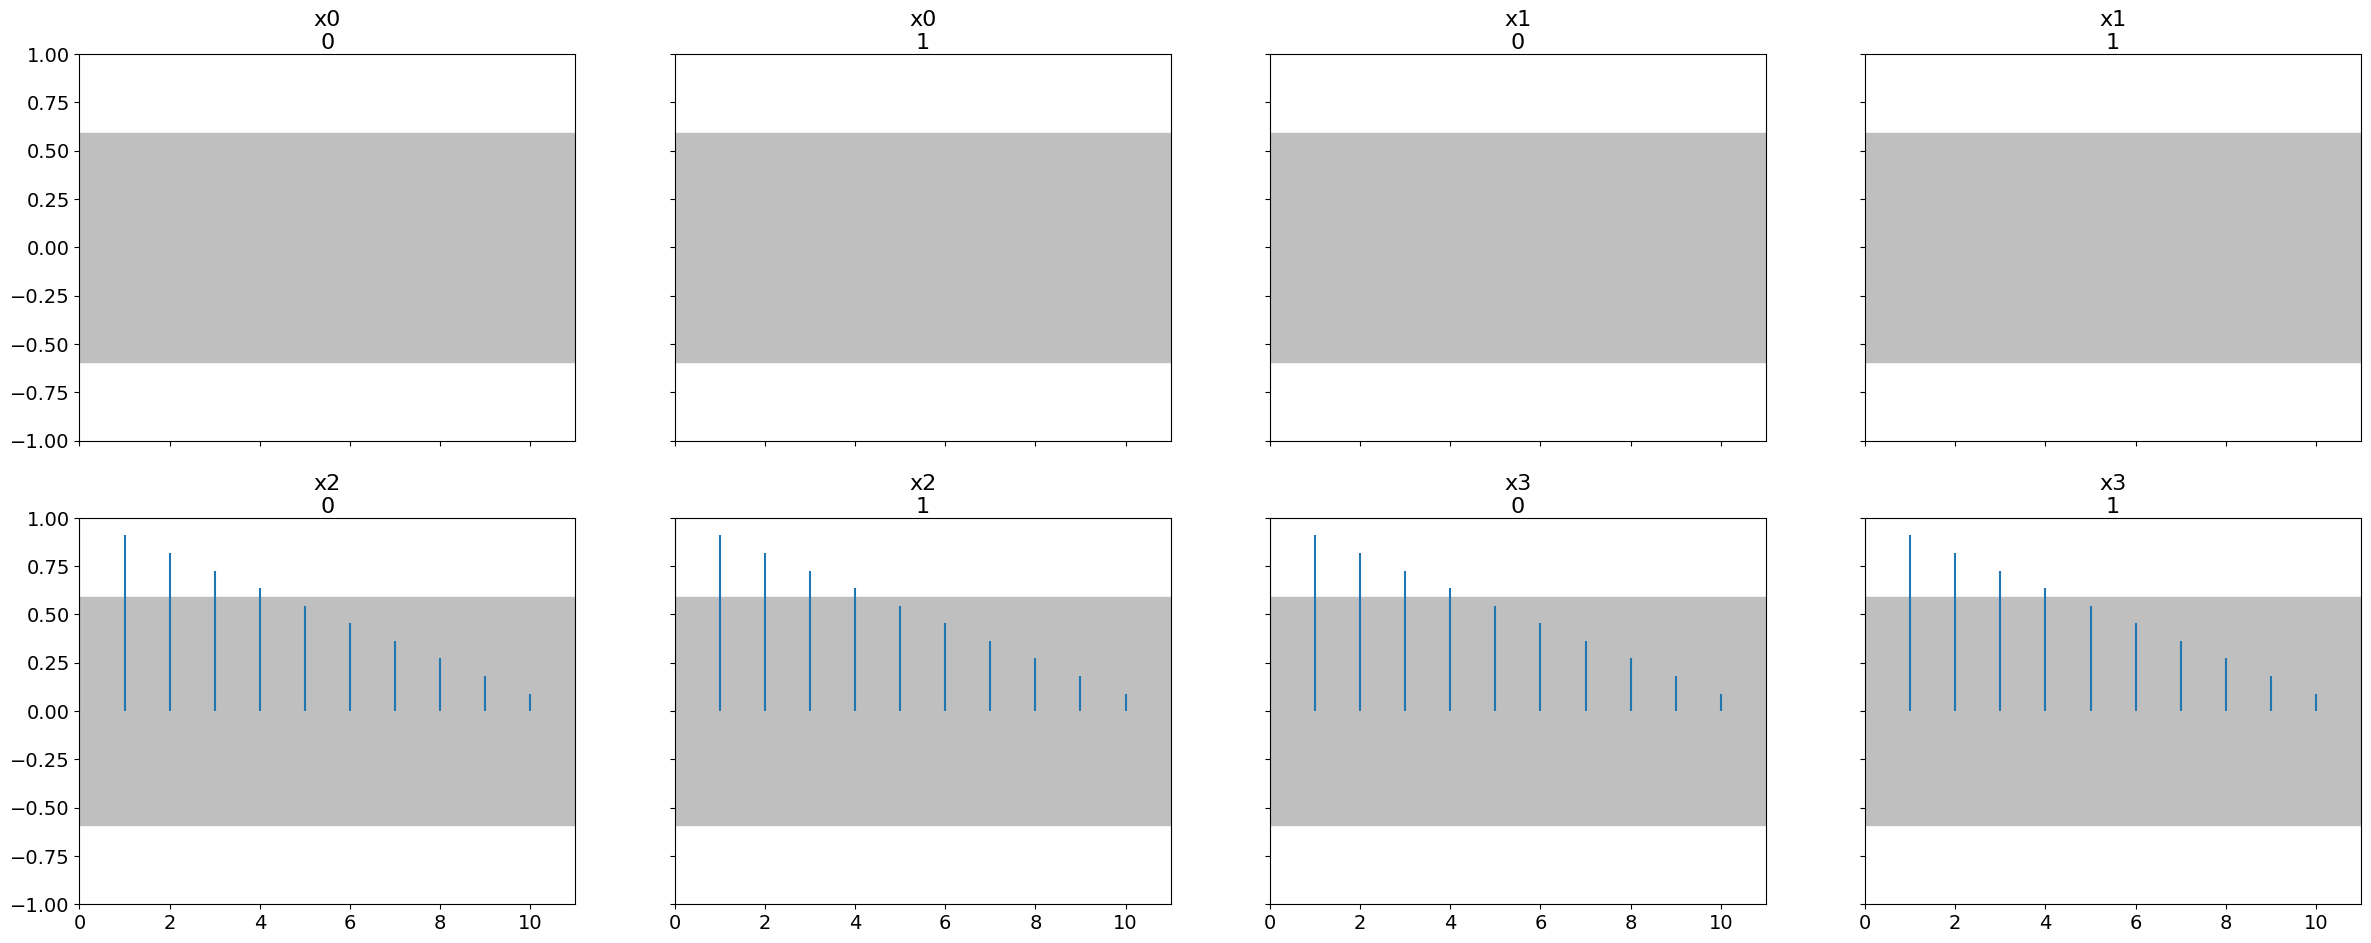

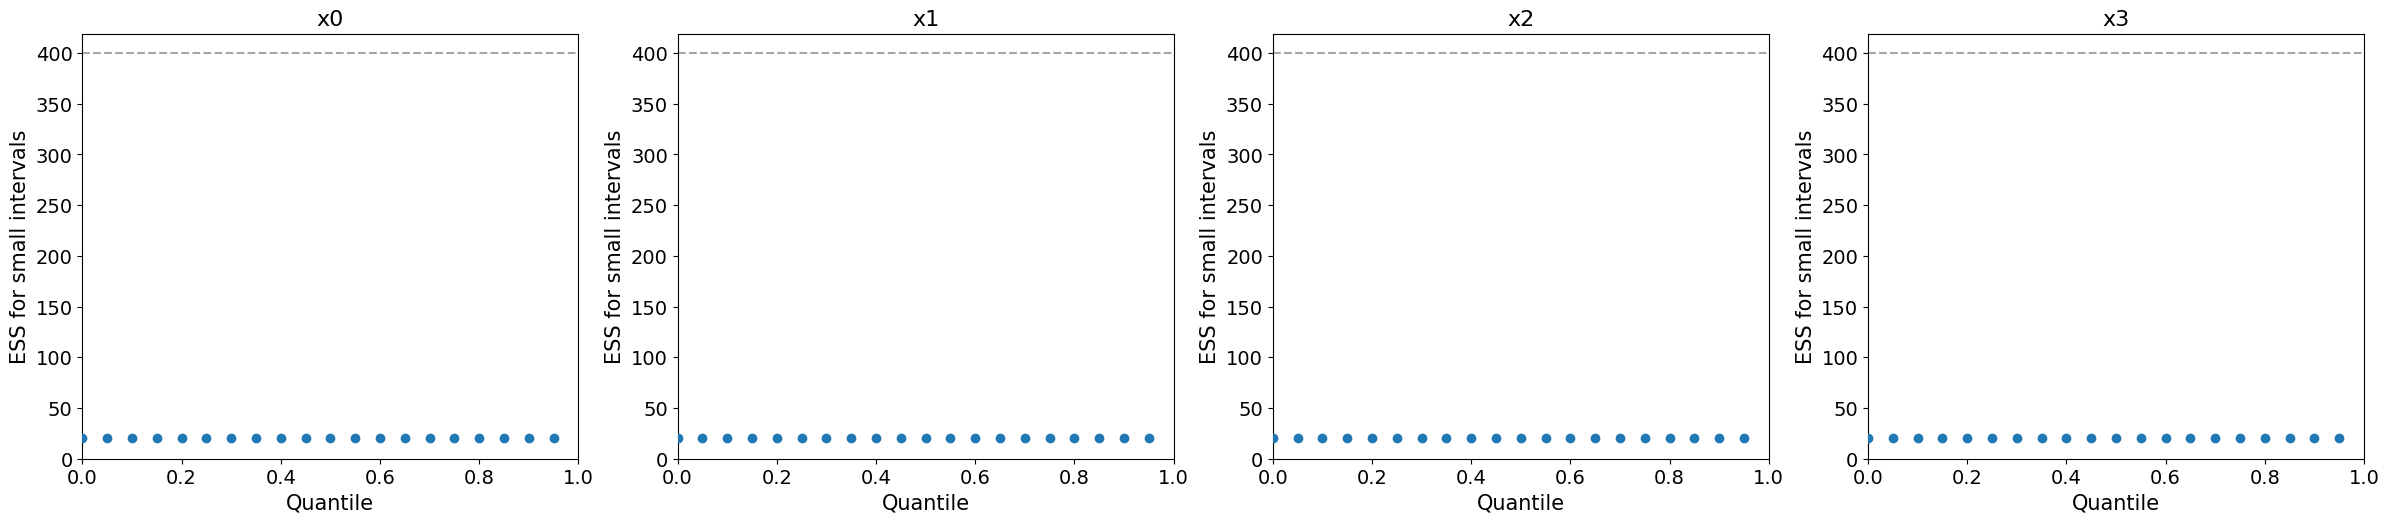

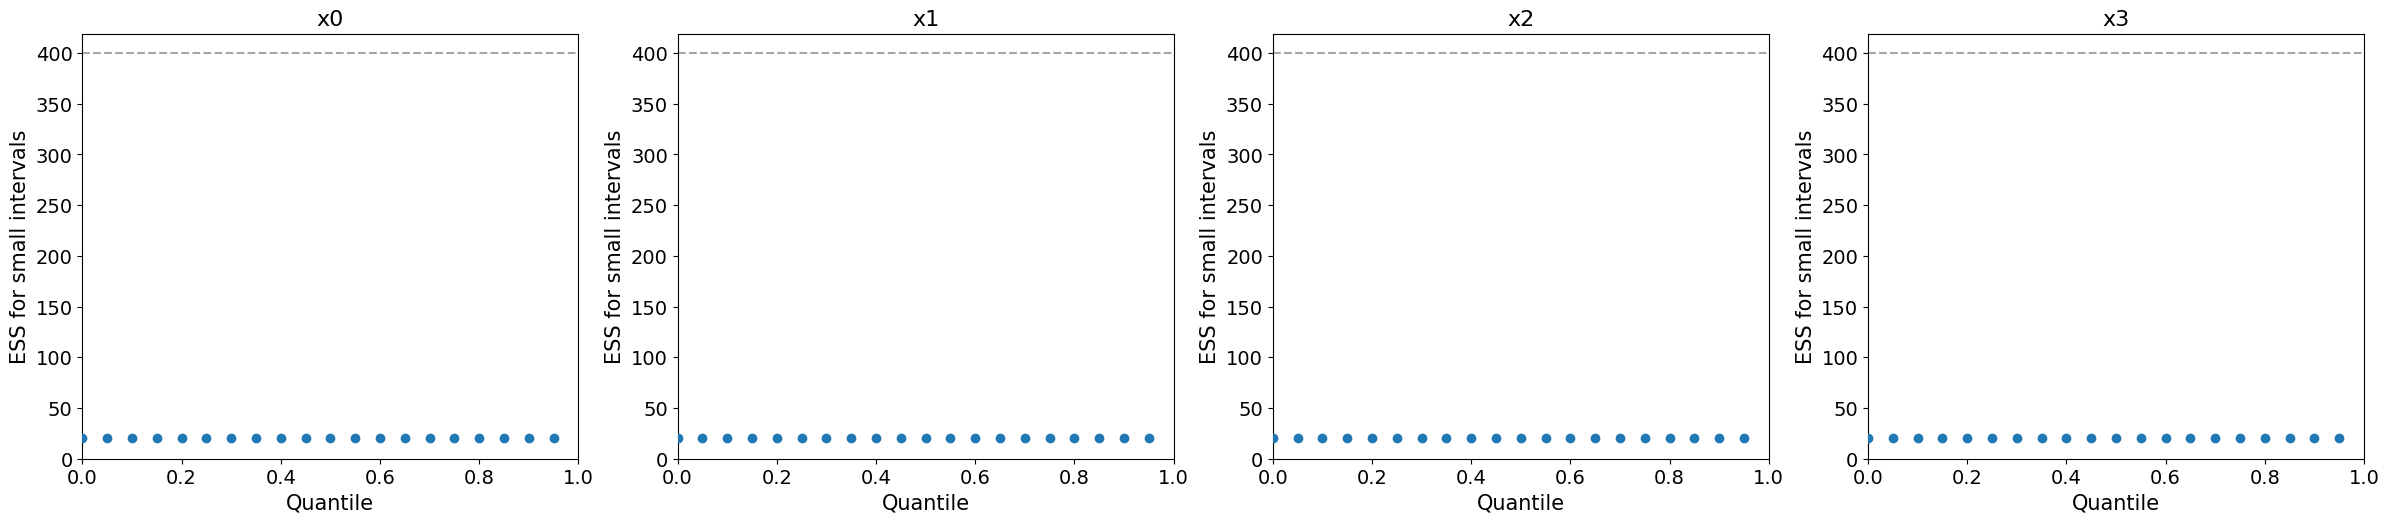

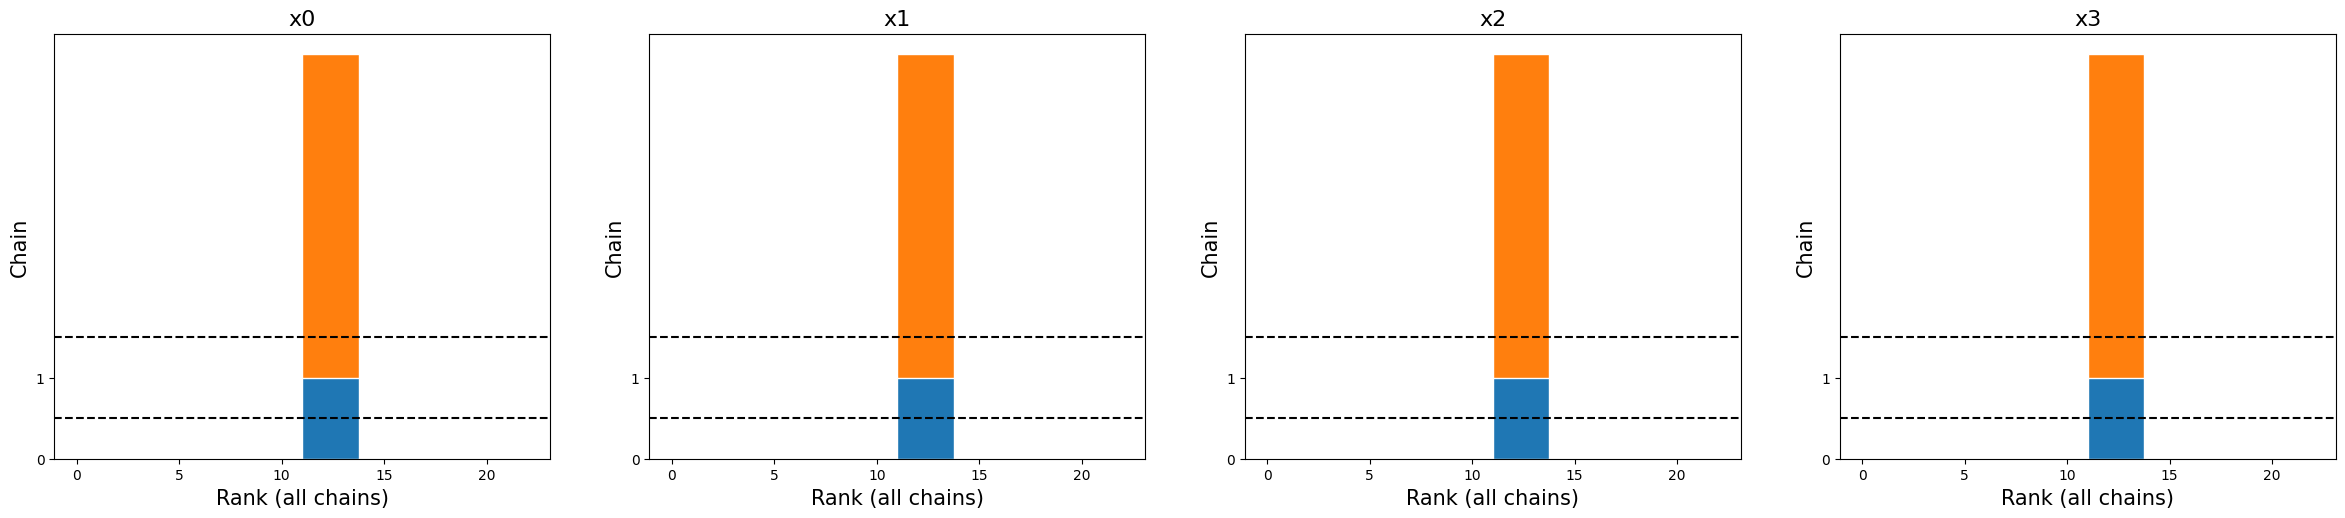

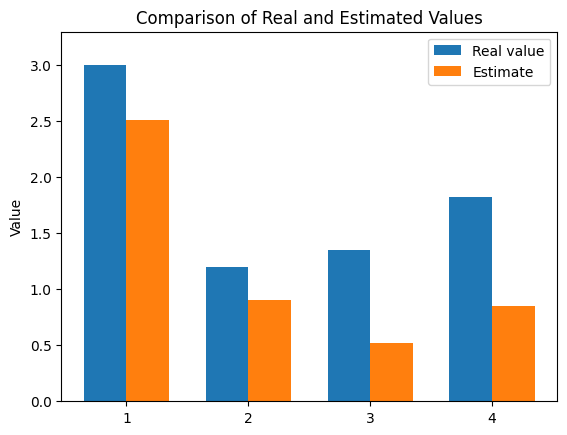

The function param_inverse took 68.561547 seconds.
Sampling 2 chains in parallel


2024-08-11 01:14:55,527	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


KeyboardInterrupt: 

In [21]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 30
burnin = 20
n_chains = 2
algo = "MH"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)
